In [1]:
# Cell 1：掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 2：匯入套件
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# =========================
# Cell 3：路徑設定
# =========================
NPZ_PATH = "/content/drive/MyDrive/Colab Notebooks/data/printed_chars_dataset.npz"

RESULT_DIR = "/content/drive/MyDrive/Colab Notebooks/results"
os.makedirs(RESULT_DIR, exist_ok=True)

RESULT_TXT = os.path.join(RESULT_DIR, "result_knn.txt")
RESULT_CSV = os.path.join(RESULT_DIR, "result_knn.csv")

# =========================
# 若 npz 不存在，自動下載
# =========================
if not os.path.exists(NPZ_PATH):
    print("找不到 npz，開始下載...")

    # 建立 data 資料夾
    os.makedirs(os.path.dirname(NPZ_PATH), exist_ok=True)

    # 使用 gdown 下載 Google Drive 檔案
    !pip install -q gdown

    import gdown

    file_id = "1OuK9eYrdlXuYl_kbjMy27dW7dgzEnL3_"
    url = f"https://drive.google.com/uc?id={file_id}"

    gdown.download(url, NPZ_PATH, quiet=False)

    print("下載完成！")
else:
    print("已找到 npz，直接使用。")

print("NPZ_PATH =", NPZ_PATH)
print("RESULT_DIR =", RESULT_DIR)

已找到 npz，直接使用。
NPZ_PATH = /content/drive/MyDrive/Colab Notebooks/data/printed_chars_dataset.npz
RESULT_DIR = /content/drive/MyDrive/Colab Notebooks/results


In [4]:
# Cell 4：讀取 npz
data = np.load(NPZ_PATH, allow_pickle=True)

images = data["images"]         # shape: (N, 28, 28)
labels = data["labels"]         # shape: (N,)
label_names = data["label_names"]
filenames = data["filenames"]

print("images.shape =", images.shape)
print("labels.shape =", labels.shape)
print("label_names =", label_names)
print("前5個檔名 =", filenames[:5])

images.shape = (1800, 28, 28)
labels.shape = (1800,)
label_names = ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
前5個檔名 = ['0_AGENCYB.png' '0_AGENCYR.png' '0_ALGER.png' '0_ANTQUAB.png'
 '0_ANTQUABI.png']


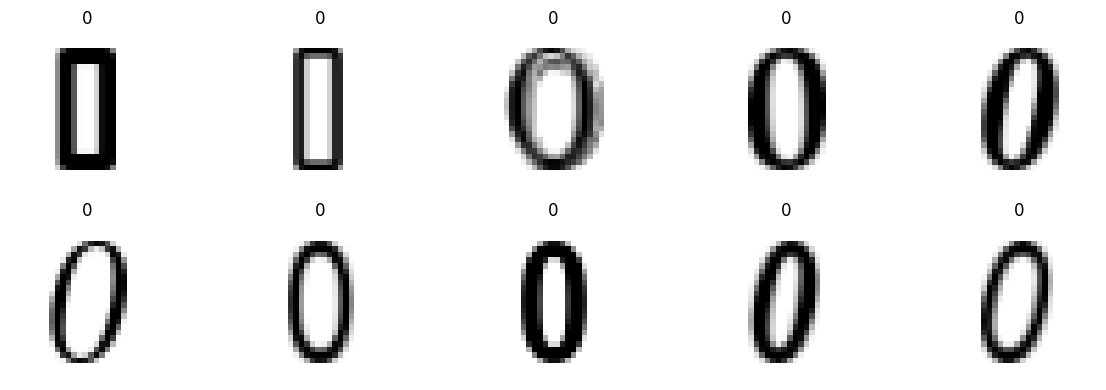

In [5]:
# Cell 5：顯示範例圖
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(f"{label_names[labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Cell 6：資料前處理
# KNN 不能直接吃 (28,28)，要先攤平成一維向量
# 將影像轉成一維向量
X = images.reshape(len(images), -1)   # shape: (N, 784)
y = labels

print("X.shape =", X.shape)
print("y.shape =", y.shape)

X.shape = (1800, 784)
y.shape = (1800,)


In [7]:
# Cell 7：切分 train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train.shape =", X_train.shape)
print("X_test.shape =", X_test.shape)
print("y_train.shape =", y_train.shape)
print("y_test.shape =", y_test.shape)

X_train.shape = (1440, 784)
X_test.shape = (360, 784)
y_train.shape = (1440,)
y_test.shape = (360,)


In [8]:
# Cell 8：建立 KNN 模型
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
print(f"KNN 模型建立完成，k = {k}")

KNN 模型建立完成，k = 3


In [9]:
# Cell 9：訓練 KNN 並計時
train_start = time.perf_counter()
knn.fit(X_train, y_train)
train_end = time.perf_counter()

train_time_sec = train_end - train_start
print(f"KNN 訓練時間: {train_time_sec:.6f} 秒")

KNN 訓練時間: 0.001911 秒


In [10]:
# Cell 10：整批推論並計時
infer_start = time.perf_counter()
y_pred = knn.predict(X_test)
infer_end = time.perf_counter()

total_infer_time_sec = infer_end - infer_start
avg_infer_time_ms = (total_infer_time_sec / len(X_test)) * 1000

print(f"KNN 整批推論時間: {total_infer_time_sec:.6f} 秒")
print(f"KNN 平均每張推論時間: {avg_infer_time_ms:.6f} ms")

KNN 整批推論時間: 0.063125 秒
KNN 平均每張推論時間: 0.175346 ms


In [11]:
# Cell 11：計算準確率
acc = accuracy_score(y_test, y_pred)

print(f"KNN Accuracy = {acc:.4f}")

KNN Accuracy = 0.8944


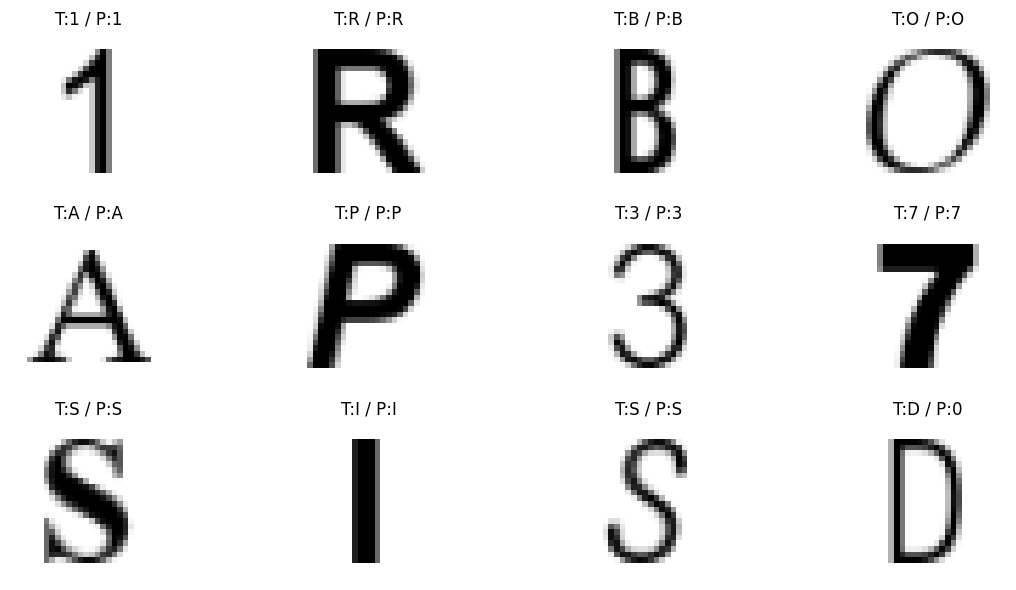

In [12]:
# Cell 12：顯示部分預測結果
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    img = X_test[i].reshape(28, 28)
    true_label = label_names[y_test[i]]
    pred_label = label_names[y_pred[i]]

    plt.imshow(img, cmap="gray")
    plt.title(f"T:{true_label} / P:{pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Cell 13：分類報告
report = classification_report(
    y_test,
    y_pred,
    target_names=label_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

           0     0.4500    0.9000    0.6000        10
           1     0.8000    0.8000    0.8000        10
           2     1.0000    1.0000    1.0000        10
           3     1.0000    0.9000    0.9474        10
           4     1.0000    0.9000    0.9474        10
           5     0.9000    0.9000    0.9000        10
           6     0.9000    0.9000    0.9000        10
           7     1.0000    1.0000    1.0000        10
           8     0.7692    1.0000    0.8696        10
           9     1.0000    0.9000    0.9474        10
           A     1.0000    1.0000    1.0000        10
           B     0.8889    0.8000    0.8421        10
           C     0.9091    1.0000    0.9524        10
           D     0.8889    0.8000    0.8421        10
           E     1.0000    0.7000    0.8235        10
           F     0.7692    1.0000    0.8696        10
           G     0.8750    0.7000    0.7778        10
           H     0.8889    

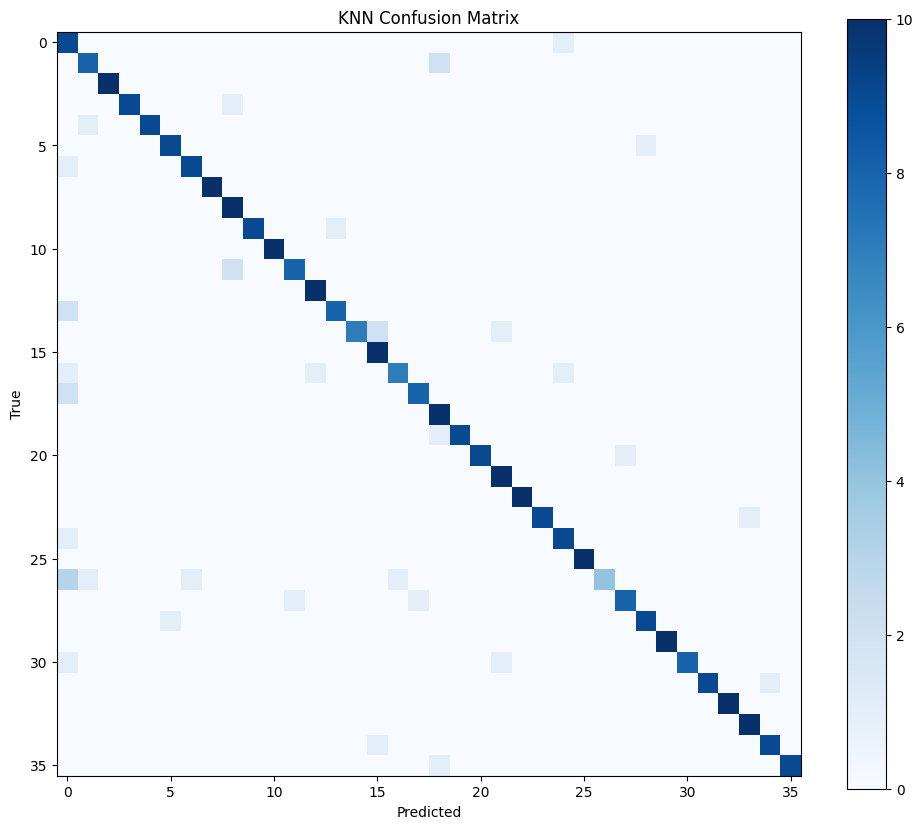

In [14]:
# Cell 14：混淆矩陣
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [15]:
# Cell 15：將結果寫入 TXT
with open(RESULT_TXT, "w", encoding="utf-8") as f:
    f.write("method=KNN\n")
    f.write("device=CPU\n")
    f.write(f"train_samples={len(X_train)}\n")
    f.write(f"test_samples={len(X_test)}\n")
    f.write(f"accuracy={acc:.6f}\n")
    f.write(f"train_time_sec={train_time_sec:.6f}\n")
    f.write(f"total_infer_time_sec={total_infer_time_sec:.6f}\n")
    f.write(f"avg_infer_time_ms={avg_infer_time_ms:.6f}\n")
    f.write(f"k={k}\n")

print(f"TXT 已儲存到：{RESULT_TXT}")

TXT 已儲存到：/content/drive/MyDrive/Colab Notebooks/results/result_knn.txt


In [16]:
# Cell 16：將摘要結果寫入 CSV
import csv

file_exists = os.path.exists(RESULT_CSV)

with open(RESULT_CSV, "a", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)

    if not file_exists:
        writer.writerow([
            "method",
            "device",
            "train_samples",
            "test_samples",
            "accuracy",
            "train_time_sec",
            "total_infer_time_sec",
            "avg_infer_time_ms",
            "extra_note"
        ])

    writer.writerow([
        "KNN",
        "CPU",
        len(X_train),
        len(X_test),
        f"{acc:.6f}",
        f"{train_time_sec:.6f}",
        f"{total_infer_time_sec:.6f}",
        f"{avg_infer_time_ms:.6f}",
        f"k={k}"
    ])

print(f"CSV 已更新：{RESULT_CSV}")

CSV 已更新：/content/drive/MyDrive/Colab Notebooks/results/result_knn.csv


1. KNN 不需要真正「學出權重」

它比較像是：

先記住訓練資料
測試時找最相近的鄰居
再用多數決分類


2. KNN 的訓練很快，但推論不一定快

因為測試時要跟很多訓練樣本比較距離。

3. 對影像來說，這裡是直接把 28x28 攤平成 784 維向量

這是很直觀但也很基礎的方法。